In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

In [ ]:
# -----------------------------
# 0) 로드
# -----------------------------
df = pd.read_csv("quality_inspection.csv", encoding="utf-8-sig")

# 컬럼명 공백/이상 정리
df.columns = [c.strip() for c in df.columns]

# -----------------------------
# 1) 핵심 전처리 함수들
# -----------------------------
# 날짜 컬럼을 datetime으로 변환
def parse_date(s: pd.Series) -> pd.Series:
    # 혼합 포맷을 최대한 흡수
    return pd.to_datetime(s, errors="coerce", infer_datetime_format=True)

def normalize_line(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip().str.upper()
    # 흔한 변형 정리
    x = x.replace({"B ": "B", " A": "A", "C-": "C", "B  ": "B", "B\t": "B", "B\n": "B"})
    x = x.replace({"B ": "B", "A ": "A", "C ": "C"})
    x = x.replace({"B": "B", "A": "A", "C": "C"})
    # 소문자 b 같은 것
    x = x.replace({"B": "B", "A": "A", "C": "C", "B": "B"})
    # 유효 라인만 남기고 나머지는 결측 처리
    x = x.where(x.isin(["A", "B", "C"]), pd.NA)
    return x

def normalize_shift(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip().str.lower()
    x = x.replace({"day": "day", "night": "night", "nigth": "night"})
    x = x.where(x.isin(["day", "night"]), pd.NA)
    return x

def normalize_inspected(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip().str.lower()
    mapping_true = {"y","1","true","t","yes"}
    mapping_false = {"n","0","false","f","no",""}
    out = pd.Series(pd.NA, index=x.index, dtype="Int64")
    out[x.isin(mapping_true)] = 1
    out[x.isin(mapping_false)] = 0
    # 혹시 숫자로 들어온 경우 대비
    # (read_csv에서 숫자로 읽혔으면 string 변환 단계에서 '1.0' 이런게 될 수 있음)
    out = out.fillna(
        pd.to_numeric(x, errors="coerce").astype("Int64")
    )
    out = out.where(out.isin([0,1]), pd.NA)
    return out

def normalize_defect(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip().str.lower()
    mapping_1 = {"1","불량","o","ok?","defect","ng"}  # 일부는 장난이지만 확장 가능
    mapping_0 = {"0","정상","x","good","pass","ok"}  # ok는 애매하지만 예시
    out = pd.Series(pd.NA, index=x.index, dtype="Int64")
    out[x.isin(mapping_1)] = 1
    out[x.isin(mapping_0)] = 0
    out = out.fillna(pd.to_numeric(x, errors="coerce").astype("Int64"))
    out = out.where(out.isin([0,1]), pd.NA)
    return out

def parse_temp(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    # '78.1C' -> '78.1', '1,234.5' -> '1234.5'
    x = x.str.replace("C", "", regex=False)
    x = x.str.replace(",", "", regex=False)
    return pd.to_numeric(x, errors="coerce")

In [3]:
# -----------------------------
# 2) 전처리 적용
# -----------------------------
df["date_parsed"] = parse_date(df["date"])
df["line_clean"] = normalize_line(df["line"])
df["shift_clean"] = normalize_shift(df["shift"])
df["inspected_clean"] = normalize_inspected(df["inspected"])
df["defect_clean"] = normalize_defect(df["defect"])
df["temp_clean"] = parse_temp(df["machine temp"])

# 요일은 date에서 재계산 (dow_raw는 믿지 않기)
df["dow_calc"] = df["date_parsed"].dt.weekday  # 0=월 ... 6=일

C:\Users\user\AppData\Local\Temp\ipykernel_12236\1747571688.py:14: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(s, errors="coerce", infer_datetime_format=True)


In [4]:
# -----------------------------
# 3) 논리 오류 처리 규칙(중요!)
# -----------------------------
# 규칙 A(추천): 검사 안 했으면 defect는 무조건 결측 처리
mask_not_inspected = (df["inspected_clean"] == 0)
df.loc[mask_not_inspected, "defect_clean"] = pd.NA

# 규칙 B: 검사 여부가 결측인 행은 분석에서 제외(또는 별도 처리)
# 여기서는 제외로 가자 (학생 과제에서는 토론 포인트로 둬도 됨)
df_analysis = df[df["inspected_clean"].isin([0,1])].copy()

# 분석 대상: "검사된 제품"만
df_inspected = df_analysis[df_analysis["inspected_clean"] == 1].copy()

# product_id 결측 제거(분석 안정성)
df_inspected = df_inspected[df_inspected["product_id"].notna()].copy()

# 완전 중복 제거(모든 컬럼 동일한 중복)
df_inspected = df_inspected.drop_duplicates()

# 온도 이상치 처리(예: 물리적으로 말이 안 되는 값 제거)
# 공장 상황에 따라 기준 다르지만, 여기서는 예시로 40~120만 남김
df_inspected.loc[~df_inspected["temp_clean"].between(40, 120), "temp_clean"] = np.nan

# 날짜 결측 제거
df_inspected = df_inspected[df_inspected["date_parsed"].notna()].copy()

# 날짜만(일 단위)로 변환
df_inspected["date_day"] = df_inspected["date_parsed"].dt.floor("D")

In [5]:
# -----------------------------
# 4) 핵심 변수 만들기(확률변수 정의)
# -----------------------------
# (1) 베르누이: 제품 1개의 불량 여부 X (0/1)
# defect_clean이 NA면 분석 불가이므로 제거
df_bern = df_inspected[df_inspected["defect_clean"].notna()].copy()
df_bern["defect_clean"] = df_bern["defect_clean"].astype(int)

# p 추정(불량률)
p_hat = df_bern["defect_clean"].mean()  # 1의 평균 = 성공확률
var_bern = p_hat * (1 - p_hat)          # Bernoulli 분산
mean_bern = p_hat                        # Bernoulli 기댓값

# (2) 하루 단위 집계: 생산/검사/불량 카운트
daily = (
    df_inspected
    .groupby("date_day")
    .agg(
        inspected_n=("product_id", "count"),
        defect_n=("defect_clean", lambda x: pd.Series(x).eq(1).sum(skipna=True)),
        defect_rate=("defect_clean", lambda x: pd.Series(x).mean(skipna=True)),
    )
    .reset_index()
)

# 포아송 λ 추정: 하루 불량 개수의 평균
# (데이터 성격상 결측/왜곡이 있을 수 있으니, defect_n이 NA가 되지 않게 위에서 처리해둠)
lambda_hat = daily["defect_n"].mean()

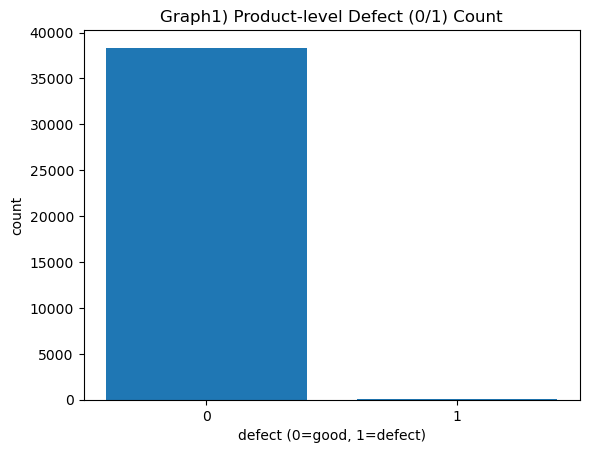

In [6]:
# -----------------------------
# 5) 그래프 5개 그리기
# -----------------------------
# 그래프 1: 제품 1개 단위 불량(0/1) 빈도
# 베르누이 분포의 현실 버전, 제품 1개는 불량이거나(1) 아니거나(0)
# 해당 그래프가 말해주는 것 : 막대가 1에 얼마나 몰려있느냐? -> 공정 품질의 수준을 파악할 수 있다
fig = plt.figure()
counts = df_bern["defect_clean"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Graph1) Product-level Defect (0/1) Count")
plt.xlabel("defect (0=good, 1=defect)")
plt.ylabel("count")
plt.show()

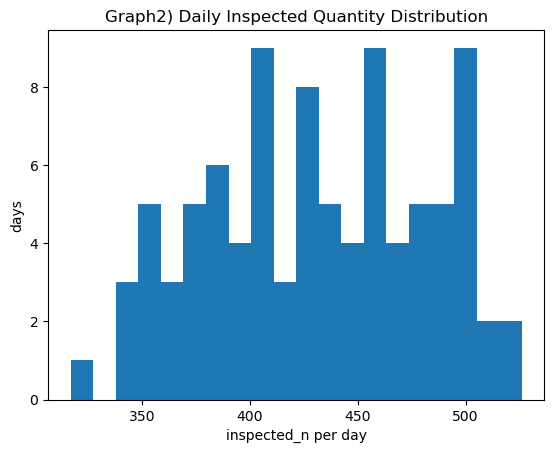

In [ ]:
# 그래프 2: 하루 검사량(inspected_n) 분포
# 노출량을 보여주는 그래프 
# 확률분포라기보다 환경 변수
# 불량 개수만 보는 것이 아니라, 불량률/단위 시간 평균의 개념이 필요함
# 포아송 분포는 시간 및 공간당 발생 횟수를 다루기 때문에 얼마나 노출되었는지를 보아야 함!
fig = plt.figure()
plt.hist(daily["inspected_n"], bins=20)
plt.title("Graph2) Daily Inspected Quantity Distribution")
plt.xlabel("inspected_n per day")
plt.ylabel("days")
plt.show()


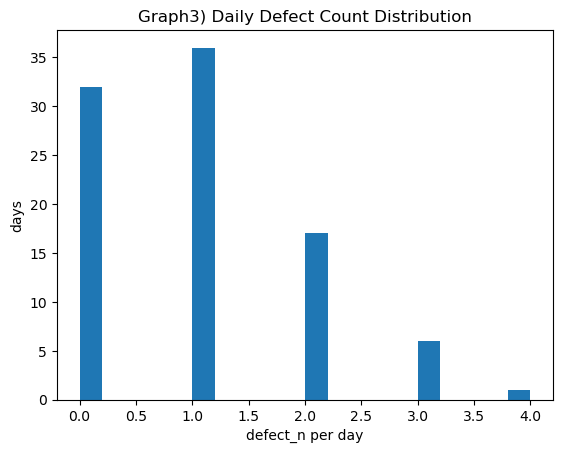

In [ ]:
# 그래프 3: 하루 불량 개수(defect_n) 분포
# x축 = 하루 불량 개수, y축 = 빈도
# 포아송 분포의 실측 히스토그램 : 하루 단위로 보면 불량 개수는 0,1,2,3… 같은 카운트 데이터
# 개별 제품은 베르누이지만 하루 단위로 묶으면 포아송 분포가 된다!!!

👉 하루 단위로 묶이면 포아송
fig = plt.figure()
plt.hist(daily["defect_n"], bins=20)
plt.title("Graph3) Daily Defect Count Distribution")
plt.xlabel("defect_n per day")
plt.ylabel("days")
plt.show()

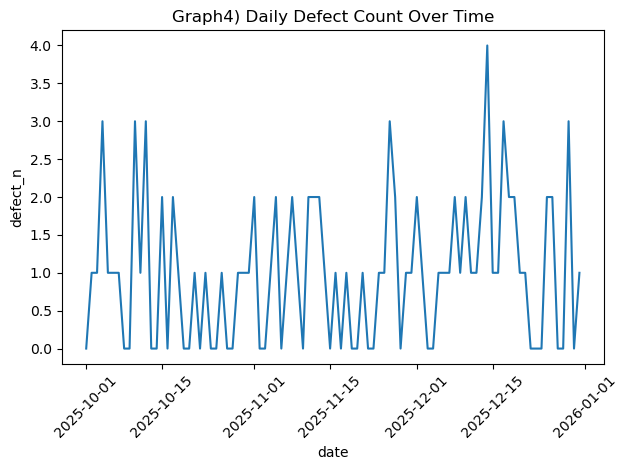

In [ ]:
# 그래프 4: 하루 불량 개수 시계열
# 분포라기 보다는 공정 상태를 감시하는 그래프!!!
# 해당 그래프를 보아야하는 이유는 현실적인 해석용이다!!
# 예를 들어 특정한 날에 갑자기 튀는 값을 확인해야 한다. 포아송 분포는 람다가 시간에 따라 일정해야하기 때문에 해당 가정을 검증하는 그래프로 볼 수 있다. 
# 분포 자체는 평균적으로 어떠한 상태인지를 보여주고, 시계열은 언제 튀는 값이 있는지 깨졌는지는 확인할 수 있다. 
fig = plt.figure()
plt.plot(daily["date_day"], daily["defect_n"])
plt.title("Graph4) Daily Defect Count Over Time")
plt.xlabel("date")
plt.ylabel("defect_n")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

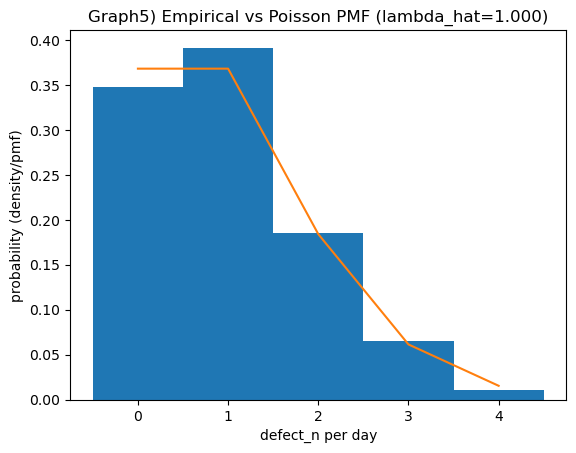

In [ ]:
# 그래프 5: 실제 히스토그램 + 포아송 이론 pmf 오버레이
# 해당 데이터를 포아송 분포로 설명해도 되는지를 확인하기 위해 같이 그래프를 그려보는 과정!!!
# 만약 그래프가 잘 겹쳐져 있다면 모델이 적합하다는 의미가 된다 >.< 

fig = plt.figure()
# 실제 분포(히스토그램) - 정수 카운트에 맞게 bins 설정
k_min, k_max = int(daily["defect_n"].min()), int(daily["defect_n"].max())
bins = np.arange(k_min - 0.5, k_max + 1.5, 1)
plt.hist(daily["defect_n"], bins=bins, density=True)

# 포아송 pmf
k = np.arange(k_min, k_max + 1)
pmf = poisson(mu=lambda_hat).pmf(k)
plt.plot(k, pmf)
plt.title(f"Graph5) Empirical vs Poisson PMF (lambda_hat={lambda_hat:.3f})")
plt.xlabel("defect_n per day")
plt.ylabel("probability (density/pmf)")
plt.show()